In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Part A
# A.1
# Clean dataset generation
np.random.seed(42)  # For reproducibility
slope = 2
intercept = 5
num_points = 10000
X_clean = np.random.rand(num_points) * 100  # Random X values between 0 and 100
noise_clean = np.random.normal(0, 2, num_points)  # Add some noise to the Y values
Y_clean = slope * X_clean + intercept + noise_clean # y = 2x + 5 + noise

**Choice of parameters made:**

The data is generated using equation : **y = ax + b + noise**

a=2, chosen to create a clear positive linear relationship between x and y.

b=5, chosen to avoid zero intercept and make the model more realistic.

σ = 2, chosen to add moderate Gaussian noise while keeping the signal dominant.

n = 10000, chosen to ensure stable estimates and reduce variance.

x ~ Uniform(0,100), chosen to provide even coverage of the input space without bias.

random seed = 42, chosen to ensure reproducibility of the dataset and consistent results across runs. 


In [3]:
# A.2
# correlated dataset generation
np.random.seed(42)  # For reproducibility
coeff_1 = 2
coeff_2 = 5
intercept = 10
num_points = 10000
X_corr = np.random.rand(num_points) * 10  
Z_corr = 2 * X_corr + np.random.normal(0, 1, num_points)  
noise_corr = np.random.normal(0, 1, num_points)  
Y_corr = coeff_1 * X_corr + coeff_2 * Z_corr + intercept + noise_corr # y = 2x + 5z + 10 + noise
X_corr_train, X_corr_test = X_corr[:8000], X_corr[8000:]
Z_corr_train, Z_corr_test = Z_corr[:8000], Z_corr[8000:]
Y_corr_train, Y_corr_test = Y_corr[:8000], Y_corr[8000:]

**Choice of parameters made:**

The data is generated using equation : **y = ax + bz + c + noise**

a=2, chosen to create a clear positive linear relationship between x and y.

b=5, chosen to avoid zero intercept and make the model more realistic.

c=10, chosen to shift the baseline and avoid origin-centered data

σ(z|x) = 1, chosen small gaussian noise to introduce strong but not perfect correlation between X and Z.

σ(noise) = 1, chosen to add small Gaussian noise while preserving signal clarity.

n = 10000, chosen to ensure stable estimates and reliable learning in multivariate setting.

x ~ Uniform(0,10), chosen to provide controlled range and avoid large-scale values.

train/test split = 8000/2000, chosen to allow sufficient training data and reliable evaluation.

random seed = 42, chosen to ensure reproducibility and consistency across multiple uses so that all random operations generate identical results across runs.


In [4]:
# Computing eigen values and condition number for correlated dataset
X = np.column_stack((X_corr, Z_corr))
xtx = X.T @ X
eigenvalues = np.linalg.eigvals(xtx)
condition_number = np.linalg.cond(xtx)
print("Eigenvalues:", eigenvalues)
print("Condition Number:", condition_number)

Eigenvalues: [   1988.02535852 1643732.16978897]
Condition Number: 826.8165004749958


In [5]:
# A.3
# Generating data with outliers
X_out = X_clean.copy()  # Reshape for consistency
Y_out = Y_clean.copy()
outlier_fraction = 0.1   # 10%
n = len(Y_clean)
num_outliers = int(n * outlier_fraction)

np.random.seed(42)  # to select indices randomly without replacement for unbiased selection of indices
outlier_indices = np.random.choice(n, num_outliers, replace=False)
large_deviation = np.random.normal(0, 50, num_outliers) # Large deviation compared to original noise (std = 2)
Y_out[outlier_indices] += large_deviation
X_out_train, X_out_test = X_out[:8000], X_out[8000:]
Y_out_train, Y_out_test = Y_out[:8000], Y_out[8000:]

**Corruption process :**

To introduce structured outliers, 10% of the samples were randomly selected without replacement. For these samples, the target variable y was corrupted by adding large deviations drawn from a Gaussian distribution with mean 0 and standard deviation 50, which is significantly larger than the original noise (σ = 2). This produces extreme deviations from the underlying linear relationship. Keeping the distribution of feature values unchanged ensures that the outliers are not easily identifiable based on feature values alone, making the dataset more realistic and challenging for regression models.

In [6]:
# Part B
# B.1
# Ordinary least square implementation
def ordinary_least_squares(X, Y):
    X_b = np.column_stack((np.ones(X.shape[0]), X))  # Add bias term
    theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ Y
    return theta

# B.2
# Gradient descent for ols
def ols_gradient_descent(X, Y, learning_rate=0.01, max_iterations=1000):
    X_b = np.column_stack((np.ones(X.shape[0]), X))  # Add bias term
    theta = np.zeros(X_b.shape[1])  # Initialize parameters
    losses = []
    m = len(Y)
    for iteration in range(max_iterations):
        predictions = X_b @ theta
        errors = predictions - Y
        loss = (1/m) * np.sum(errors ** 2)
        gradients = (2/m) * X_b.T @ errors
        theta -= learning_rate * gradients
        losses.append(loss)
    return theta, losses

# B.3
# Ridge closed form
def ridge_closed_form(X, Y, alpha=1.0):
    X_b = np.column_stack((np.ones(X.shape[0]), X))  # Add bias term
    I = np.eye(X_b.shape[1])
    I[0, 0] = 0  # Do not regularize the bias term
    theta = np.linalg.inv(X_b.T @ X_b + alpha * I) @ (X_b.T @ Y)
    return theta

# Ridge gradient descent
def ridge_gradient_descent(X, Y, alpha=1.0, learning_rate=0.01, max_iterations=1000):
    X_b = np.column_stack((np.ones(X.shape[0]), X))  # Add bias term
    theta = np.zeros(X_b.shape[1])  # Initialize parameters
    m = len(Y)
    for iteration in range(max_iterations):
        gradients = (2/m) * X_b.T @ (X_b @ theta - Y) + 2 * alpha * np.r_[0, theta[1:]]  # Do not regularize the bias term
        theta -= learning_rate * gradients   
    return theta

# B.4
# Lasso regression via subgradient descent
def lasso_subgradient_descent(X, Y, alpha=1.0, learning_rate=0.01, max_iterations=1000):
    X_b = np.column_stack((np.ones(X.shape[0]), X))  # Add bias term
    theta = np.zeros(X_b.shape[1])  # Initialize parameters
    m = len(Y)
    for iteration in range(max_iterations):
        predictions = X_b @ theta
        errors = predictions - Y
        subgradients = (2/m) * X_b.T @ errors  # L1 regularization subgradient
        subgradients[1:] += alpha * np.sign(theta[1:])  # Do not regularize the bias term
        theta -= learning_rate * subgradients   
    return theta

# B.5
# Weighted least squares closed form 
def weighted_least_squares_closed_form(X, Y, weights):
    X_b = np.column_stack((np.ones(X.shape[0]), X))  # Add bias term
    W = np.diag(weights)  # Create diagonal weight matrix
    theta = np.linalg.inv(X_b.T @ W @ X_b) @ (X_b.T @ W @ Y)
    return theta

**Equation of closed-form ordinary least squares**

w=(X^T X)^{-1} X^T y

where:
- w is the weight vector (parameters) we are trying to learn.
- X is the feature matrix (n x d), where n is the number of samples and d is the number of features.
- y is the target vector (n x 1), containing the true target values for each

**Equation of Gradient descent for OLS**

w := w - α * (2/n) * X^T (Xw - y)

Where:
- w is the weight vector (parameters) we are trying to learn.
- α is the learning rate, which controls the step size of each update.
- n is the number of samples in the dataset.
- X is the feature matrix (n x d), where n is the number of samples and d is the number of features.
- y is the target vector (n x 1), containing the true target values for each sample.

**Equation of closed-form Ridge regression**

w = (X^T X + λI)^{-1} X^T y

Where:
- w is the weight vector (parameters) we are trying to learn.
- X is the feature matrix (n x d), where n is the number of samples and d is the number of features.
- y is the target vector (n x 1), containing the true target values for each sample.
- λ is the regularization parameter.
- I is the identity matrix of size d x d.

**Equation of ridge gradient descent**

w := w - α * ((2/n) * X^T * (Xw - y) + 2λw)

Where:
- w is the weight vector (parameters) we are trying to learn.
- α is the learning rate, which controls the step size of each update.
- n is the number of samples in the dataset.
- X is the feature matrix (n x d).
- y is the target vector (n x 1).
- λ is the regularization parameter.
- I is the identity matrix of size d x d.

**Equation of Lasso sub-gradient descent**

w := w - α * ((2/n) * X^T * (Xw - y) + λ * sign(w))

Where:
- w is the weight vector (parameters) we are trying to learn.
- α is the learning rate, which controls the step size of each update.
- n is the number of samples in the dataset.
- X is the feature matrix (n x d).
- y is the target vector (n x 1).
- λ is the regularization parameter.
- sign(w) is the sub-gradient of the L1 norm.

**Equation of Weighted Least Squares**

w = (X^T W X)^{-1} X^T W y

Where:
- w is the weight vector (parameters) we are trying to learn.
- X is the feature matrix (n x d).
- y is the target vector (n x 1).
- W is the diagonal matrix of weights.

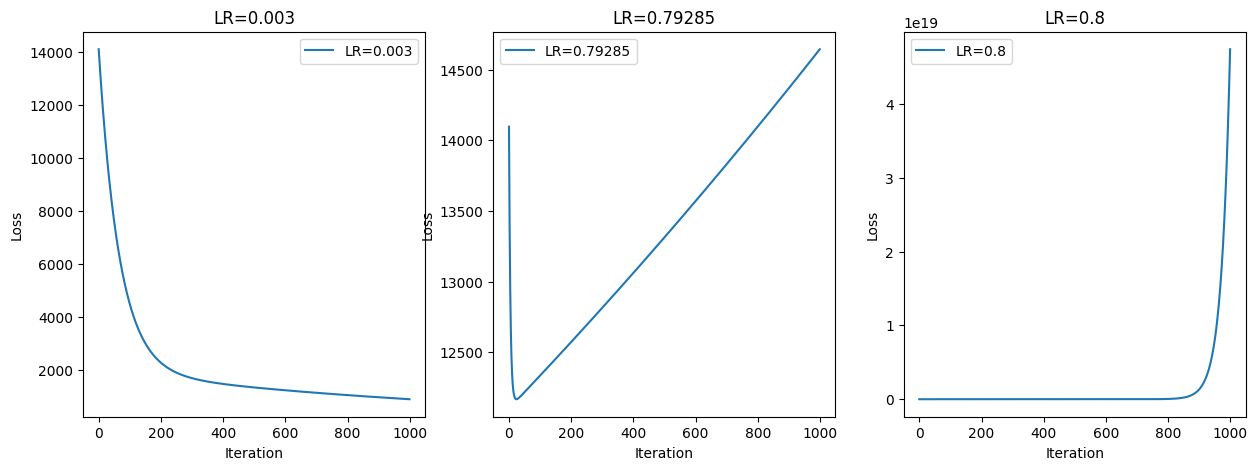

In [7]:
# Part C
# C.1
# Training OLS with different learning rates and plotting loss curves
learning_rates = [0.003, 0.79285, 0.8]
results = {}
for lr in learning_rates:
    theta, losses = ols_gradient_descent(X_clean/100, Y_clean, learning_rate=lr)
    results[lr] = losses
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, (lr, losses) in enumerate(results.items()):
    axes[i].plot(losses, label=f'LR={lr}')
    axes[i].set_title(f'LR={lr}')
    axes[i].set_xlabel('Iteration')
    axes[i].set_ylabel('Loss')
    axes[i].legend()

The learning rate for convergence of gradient descent is 0.003.

The learning rate value for oscillations is 0.79285. Very less oscillation is visible at this learning rate because of the sharp transition from convergence to divergence. The learning rate value for oscillations is very close to the critical learning rate, which is 0.8, and it is expected that the updates will oscillate around the optimal parameters without diverging.

The learning rate value for divergence is 0.8.

In [8]:
# C.2
x = X_clean/100
x_b = np.column_stack((np.ones(x.shape[0]), x))  # Add bias term
m = len(Y_clean)
xtx = (2/m) * (x_b.T @ x_b)
eigenvalues = np.linalg.eigvals(xtx)
max_eignenvalue = np.max(eigenvalues)
print("Eigenvalues:", eigenvalues)
print("Max Eigenvalue:", max_eignenvalue)
print("critical learning rate (2/max_eigenvalue):", 2/max_eignenvalue)

Eigenvalues: [2.52266566 0.13116731]
Max Eigenvalue: 2.522665661038474
critical learning rate (2/max_eigenvalue): 0.7928121553677014


**Relation**

In the OLS method for gradient descent, gradient of the loss function is given by **(2/m) * X^T * (Xw - y)** When we multiply this as **(2/m) * X^T * Xw - (2/m) * X^T * y**, the first term is the hessian matrix (**2/m * X^T * X**) which determines the curvature of the loss function. The convergence of gradient descent is influenced by the laargest eigenvalue of this hessian matrix because the weight update equation becomes **w = w - learning_rate * (hessian_matrix * w - (2/m) * X^T * y)**. This clearly shows that the learning rate depends on the largest eigen value of the hessian matrix. If the learning rate is too large, it can lead to divergence of the gradient descent algorithm, while a smaller learning rate ensures convergence towards the optimal solution.

**Statement**

For Linear regression, the loss function is quadratic and its curvature determined by the hessian matrix **2/m * X^T * X**. The convergence depends on the largest eigen value of the hessian matrix. The critical learning rate is given by **2/max_eigenvalue**, where max_eigenvalue is the largest eigenvalue of the hessian matrix. If the learning rate exceeds this critical value, the gradient descent may diverge. Therefore, understanding the eigenvalues helps in selecting an appropriate learning rate for training the linear regression model effectively.

**Verification**

For the clean dataset, the maximum eigen value of hessian matix is 2.522665661038474, which gives us a critical learning rate of 
0.7928121553677014. For this dataset any value of learning rate less than 0.7928121553677014 will ensure convergence of the gradient descent algorithm. Whereas the value of learning rate greater than 0.7928121553677014 will lead to divergence of the gradient descent algorithm as shown in previous loss vs lr plots.

**C.3**

In linear regression, the loss function is quadratic, so its curvature varies across different directions in parameter space. This curvature is captured by the Hessian matrix, and its eigenvalues indicate how steep the loss surface is along each direction.
When we analyze gradient descent using the eigen-decomposition of the Hessian matrix, the updates along each eigen-direction become independent. In each direction, the update depends on both the learning rate and the corresponding eigenvalue.

For gradient descent to converge, updates in every direction must decrease in magnitude over time. This creates a constraint on the learning rate for each direction. The direction associated with the largest eigenvalue represents the highest curvature (steepest direction) of the loss function.Since this direction is the most sensitive to the learning rate, it imposes the strictest condition for stability. If the learning rate is too large, updates in this direction will overshoot and diverge, even if updates in other directions remain stable.

Therefore, the maximum eigenvalue determines the convergence bound of gradient descent because it governs the most restrictive condition required for convergence across all directions.

In [9]:
# Part D
# D.1
# Computing eigen values and condition number for correlated dataset
X = np.column_stack((X_corr, Z_corr))
xtx = X.T @ X
eigenvalues = np.linalg.eigvals(xtx)
condition_number = np.linalg.cond(xtx)
print("Eigenvalues:", eigenvalues)
print("Condition Number:", condition_number)

Eigenvalues: [   1988.02535852 1643732.16978897]
Condition Number: 826.8165004749958


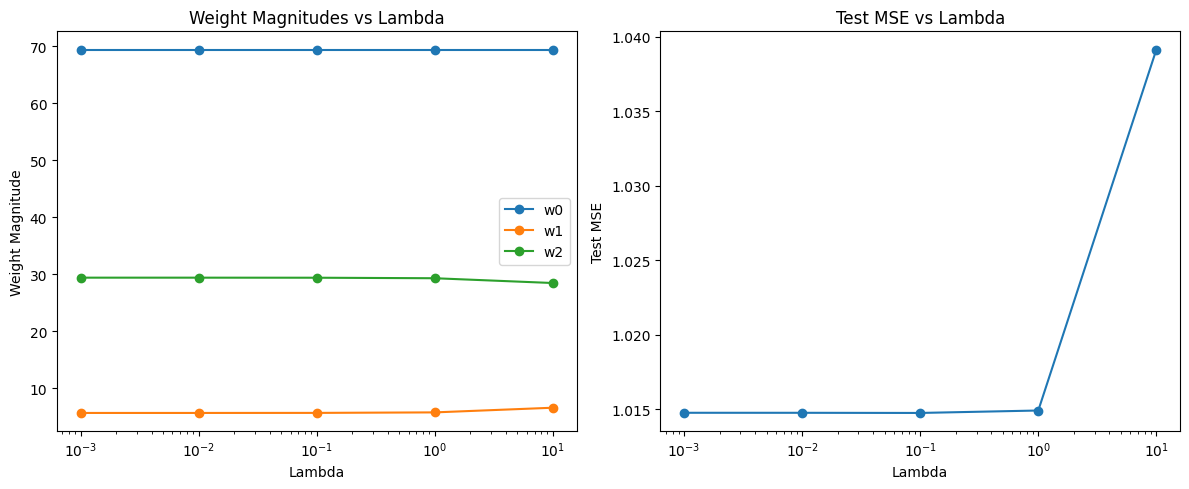

In [10]:
# D.2
X_train = np.column_stack((X_corr_train, Z_corr_train))
X_test = np.column_stack((X_corr_test, Z_corr_test))
# Feature scaling to make effects of lambda on weight visible
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# Adding bias term
X_train = np.column_stack((np.ones(X_train.shape[0]), X_train))
X_test = np.column_stack((np.ones(X_test.shape[0]), X_test))
y_train = Y_corr_train
y_test = Y_corr_test

# Weight using OLS closed form
w_ols = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train

# Calculating weights and MSE for different lambda values
lambdas = [0.001, 0.01, 0.1, 1, 10]
weights = []
mse_value = []
for lam in lambdas:
    I = np.eye(X_train.shape[1])
    I[0, 0] = 0  
    w_ridge = np.linalg.inv(X_train.T @ X_train + lam * I) @ X_train.T @ y_train
    weights.append(w_ridge)
    y_pred = X_test @ w_ridge
    mse = np.mean((y_test - y_pred) ** 2)
    mse_value.append(mse)
weights = np.array(weights)

plt.figure(figsize=(12, 5))
# Weight Magnitudes vs Lambda 
plt.subplot(1, 2, 1)
for i in range(weights.shape[1]):
    plt.plot(lambdas, np.abs(weights[:, i]), marker='o', label=f'w{i}')
plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('Weight Magnitude')
plt.title('Weight Magnitudes vs Lambda')
plt.legend()

# MSE vs Lambda
plt.subplot(1, 2, 2)
plt.plot(lambdas, mse_value, marker='o')
plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('Test MSE')
plt.title('Test MSE vs Lambda')
plt.tight_layout()
plt.show()

**D.3**

Adding λI to X^TX increases all its eigenvalues by λ, especially lifts the smaller eigenvalues that are close to zero. The condition number depends on the ratio of the largest to the smallest eigenvalue, so increasing the smallest eigenvalues reduces this ratio and improves conditioning. A well-conditioned matrix is numerically more stable to invert, meaning small changes or noise in data do not cause large changes in the solution. In the original X^TX, highly correlated features can make some eigenvalues very small, leading to instability and large coefficients. By adding λI, Ridge ensures that no direction in parameter space has near-zero curvature. This prevents the solution from exploding along ill-conditioned directions. As a result, the computed weights become more stable and less sensitive to noise. Overall, λI acts as a regularizer that improves numerical stability and robustness of the solution.

OLS (Closed-form)
  Weights (original scale): [5.05169452 2.00115478]
  Training MSE: 241.6015

OLS (GD)
  Weights (original scale): [5.05169451 2.00115477]
  Training MSE: 241.6015

Ridge
  Weights (original scale): [54.55906156  1.00057739]
  Training MSE: 1077.6308

Lasso
  Weights (original scale): [5.90780351 1.98385223]
  Training MSE: 241.8515



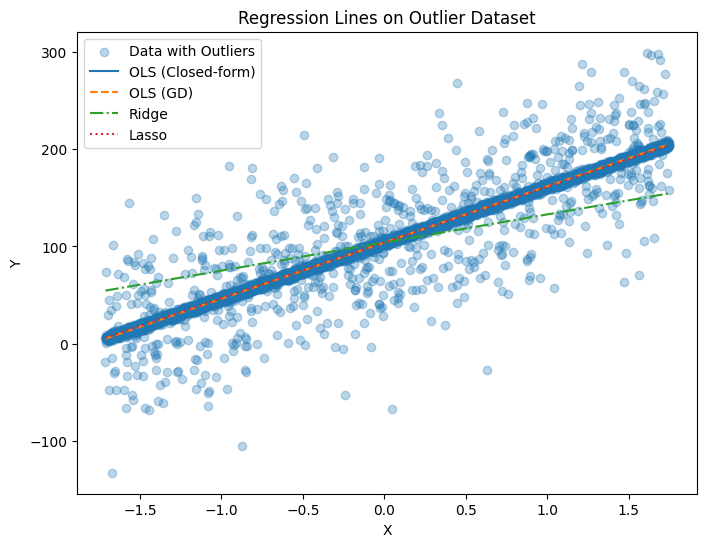

In [11]:
# Part E
# E.1
# Train models
mean=X_out_train.mean()
std=X_out_train.std()
X_out_train_scaled = (X_out_train - mean) / std
theta_ols_cf = ordinary_least_squares(X_out_train_scaled, Y_out_train)
theta_ols_gd, _ = ols_gradient_descent(X_out_train_scaled, Y_out_train)
theta_ridge = ridge_gradient_descent(X_out_train_scaled, Y_out_train, alpha=1.0)
theta_lasso = lasso_subgradient_descent(X_out_train_scaled, Y_out_train, alpha=1.0)

def predict(X, theta):
    X_b = np.column_stack((np.ones(X.shape[0]), X))
    return X_b @ theta
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)
def convert_weights(theta, mean, std):
    theta0, theta1 = theta
    b1 = theta1 / std
    b0 = theta0 - (theta1 * mean / std)
    return np.array([b0, b1])

models = {
    "OLS (Closed-form)": theta_ols_cf,
    "OLS (GD)": theta_ols_gd,
    "Ridge": theta_ridge,
    "Lasso": theta_lasso
}
for name, theta in models.items():
    preds = predict(X_out_train_scaled, theta)
    error = mse(Y_out_train, preds)
    theta_orig = convert_weights(theta, mean, std)
    print(f"{name}")
    print(f"  Weights (original scale): {theta_orig}")
    print(f"  Training MSE: {error:.4f}\n")
# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(X_out_train_scaled, Y_out_train, alpha=0.3, label="Data with Outliers")

# Line plotting range
x_vals = np.linspace(X_out_train_scaled.min(), X_out_train_scaled.max(), 100).reshape(-1,1)

# Plot each model
styles = {
    "OLS (Closed-form)": "-",
    "OLS (GD)": "--",
    "Ridge": "-.",
    "Lasso": ":"
}
for name, theta in models.items():
    y_vals = predict(x_vals, theta)
    plt.plot(x_vals, y_vals, label=name, linestyle=styles[name])

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Regression Lines on Outlier Dataset")
plt.legend()
plt.show()

**E.2**

OLS (both closed-form and gradient descent) is the least robust to outliers because it minimizes squared error, causing it to heavily adjust the regression line to fit extreme values. This is evident in the plot where the OLS line is strongly influenced by outliers, resulting in a steeper slope. Lasso behaves similarly to OLS in this case, as the regularization strength is not sufficient to significantly alter the coefficients, leading to nearly identical performance and MSE. Ridge regression applies L2 regularization, which penalizes large weights and shrinks the slope, making the model less sensitive to extreme variations. However, in this dataset, Ridge shrinks the slope too much, causing underfitting and a significantly higher training MSE. Thus, while Ridge is theoretically more robust to outliers, its strong regularization leads to poorer fit here. Overall, OLS and Lasso achieve lower training error, but Ridge demonstrates robustness at the cost of increased bias.

In [12]:
# Part F
# F.1
# Implemntation of Iterativerly Reweighted Least Squares (IRLS)
def irls(X, Y, max_iter=50, tol=1e-6):
    n = X.shape[0]
    gamma = np.ones(n)
    # Store history for plotting
    theta_history = []
    gamma_history = []
    for it in range(max_iter):
        theta = weighted_least_squares_closed_form(X, Y, gamma)
        theta_history.append(theta.copy())
        gamma_history.append(gamma.copy())
        # Predictions
        X_b = np.column_stack((np.ones(n), X))
        y_pred = X_b @ theta
        # update weights
        residuals = np.abs(Y - y_pred)
        new_gamma = 1 / (1 + residuals)
        # Convergence check on the basis of tolerance of change in gamma
        if np.linalg.norm(new_gamma - gamma) < tol:
            print(f"Converged at iteration {it+1}")
            break
        gamma = new_gamma
    return theta, theta_history, gamma_history
theta_final, theta_hist, gamma_hist = irls(X_out_train, Y_out_train)

Converged at iteration 20


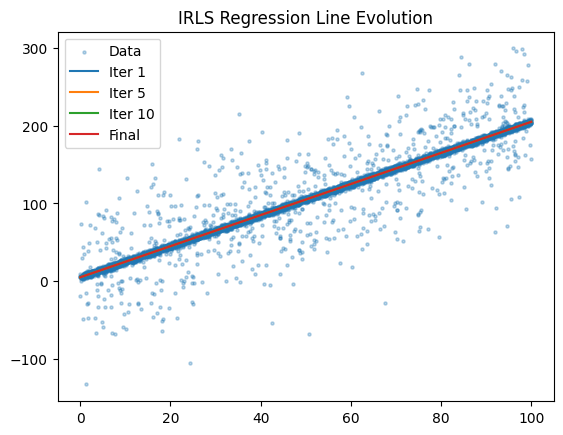

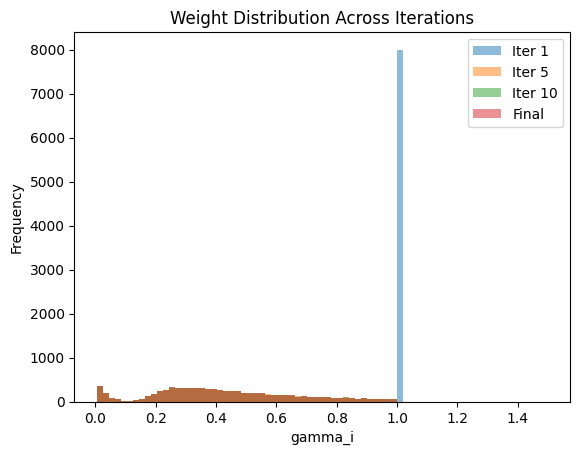

In [13]:
# F.2
# Plot the evolution of the regression line
def plot_regression_evolution(X, Y, theta_hist):
    plt.scatter(X, Y, s=5, alpha=0.3, label="Data")
    x_line = np.linspace(X.min(), X.max(), 100)
    iterations_to_plot = [0, 4, 9, len(theta_hist)-1]
    labels = ["Iter 1", "Iter 5", "Iter 10", "Final"]
    for idx, label in zip(iterations_to_plot, labels):
        theta = theta_hist[idx]
        y_line = theta[0] + theta[1] * x_line
        plt.plot(x_line, y_line, label=label)
    
    plt.legend()
    plt.title("IRLS Regression Line Evolution")
    plt.show()

# Plot the distribution of weights
def plot_weight_distribution(gamma_hist):
    iterations_to_plot = [0, 4, 9, len(gamma_hist)-1]
    labels = ["Iter 1", "Iter 5", "Iter 10", "Final"]
    
    for idx, label in zip(iterations_to_plot, labels):
        plt.hist(gamma_hist[idx], bins=50, alpha=0.5, label=label)
    
    plt.legend()
    plt.title("Weight Distribution Across Iterations")
    plt.xlabel("gamma_i")
    plt.ylabel("Frequency")
    plt.show()
plot_regression_evolution(X_out_train, Y_out_train, theta_hist)
plot_weight_distribution(gamma_hist)

**F.3**

The IRLS (Iteratively Reweighted Least Squares) method converges successfully, as indicated by stabilization of the weights after around 20 iterations, although the regression parameters themselves converge much earlier. The minimal change in regression lines across iterations suggests that the model reaches a stable solution quickly. The method effectively down-weights outliers, which is evident from the weight distribution where most outliers receive very small weights while inliers retain higher weights. However, since the proportion of outliers is relatively small, their influence on the regression line is limited even in OLS. As a result, the final IRLS regression line appears very similar to the OLS line. Compared to Ridge regression, which shrinks all coefficients uniformly, IRLS selectively reduces the influence of only high-residual points, making it more robust to outliers. Overall, IRLS provides robustness, but in this dataset, the visual difference from OLS and Ridge is minimal due to the dominance of clean data.